# Comparación de funciones de índice

El presente *notebook* incluye una comparación entre las distintas funciones de
índice implementadas, calculadas a partir de un mismo objeto
`TravelTimeMatrices` (con tiempos de viaje a supermercados en el área urbana
del Gran Concepción).

In [1]:
import datetime
from pathlib import Path

import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors

import xmin
from xmin.dataset import extract_osm_subset
from xmin.indices import (
    BinaryIndex,
    NexiGlobal,
    TwoStepFca,
    EnhancedTwoStepFca,
)

In [34]:
RAW_DATA_PATH = Path("../../data/raw")  # datos no procesados
PRE_DATA_PATH = Path("../../data/processed")  # datos preprocesados
IMG_PATH = Path("../../reports/figures")
xmin.config.quackosm_working_directory = Path("../../data/interim/quackosm")

In [3]:
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"

CENSO_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
OSM_CONCEPCION_PATH = PRE_DATA_PATH / "osm" / "Concepcion.osm.pbf"

## Orígenes, destinos y TTM

In [4]:
# carga de datos
limites_urbanos_full = gpd.read_file(
    CENSO_PATH,
    layer="Limite_Urbano_CPV24",
)

# filtramos solo las áreas de interés
limites_urbanos = limites_urbanos_full[
    (limites_urbanos_full["LOCALIDAD"] == "GRAN CONCEPCIÓN")
]

# obtenemos envoltura convexa para extraer POIs y red vial
limites_envoltura = limites_urbanos.union_all().convex_hull

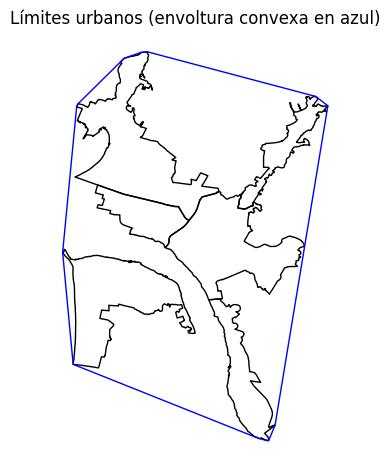

In [5]:
ax = limites_urbanos.plot(facecolor="none", edgecolor="black")
gpd.GeoSeries([limites_envoltura]).plot(
    ax=ax, facecolor="none", edgecolor="blue"
)
ax.set_axis_off()
plt.title("Límites urbanos (envoltura convexa en azul)")
plt.tight_layout()

In [6]:
manzanas = gpd.read_file(
    CENSO_PATH,
    layer="Manzanas_CPV24",
    mask=limites_urbanos.union_all(),
    use_arrow=True
).rename(columns={"n_per": "population"})

In [7]:
origins = xmin.Origins.create_grid(
    regions=limites_urbanos,
    h3_resolution=9,
    population_gdf=manzanas
)

In [8]:
if not OSM_CONCEPCION_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_CONCEPCION_PATH,
        bounds=limites_envoltura
    )

In [20]:
supermercados = xmin.Amenity.from_osm(
    name="supermercados",
    osm_path=OSM_CONCEPCION_PATH,
    osm_filter={"shop": ["supermarket"]},
)

In [21]:
ttms = xmin.TravelTimeMatrices.compute(
    origins=origins,
    amenities=[supermercados],
    gtfs_paths=[],
    osm_path=OSM_CONCEPCION_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=30),
    transport_modes=["WALK"],
    chunk_size=50
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/1927 [00:00<?, ?it/s]

## Cálculo de índices

In [22]:
acc_binary = xmin.AccessibilityRatings.compute(
    ttms,
    index_function=BinaryIndex(15)
)

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
acc_nexi = xmin.AccessibilityRatings.compute(
    ttms,
    index_function=NexiGlobal(best_time=15)
)

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

In [24]:
acc_2sfca = xmin.AccessibilityRatings.compute(
    ttms,
    index_function=TwoStepFca(threshold=15, desired_ratio=3_000)
)

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
acc_e2sfca = xmin.AccessibilityRatings.compute(
    ttms,
    index_function=EnhancedTwoStepFca(
        catchment_areas=[
            (0, 10, 1.00),
            (10, 20, 0.42),
            (20, 30, 0.03),
        ],
        desired_ratio=3_000,
    ),
)

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

## Visualización

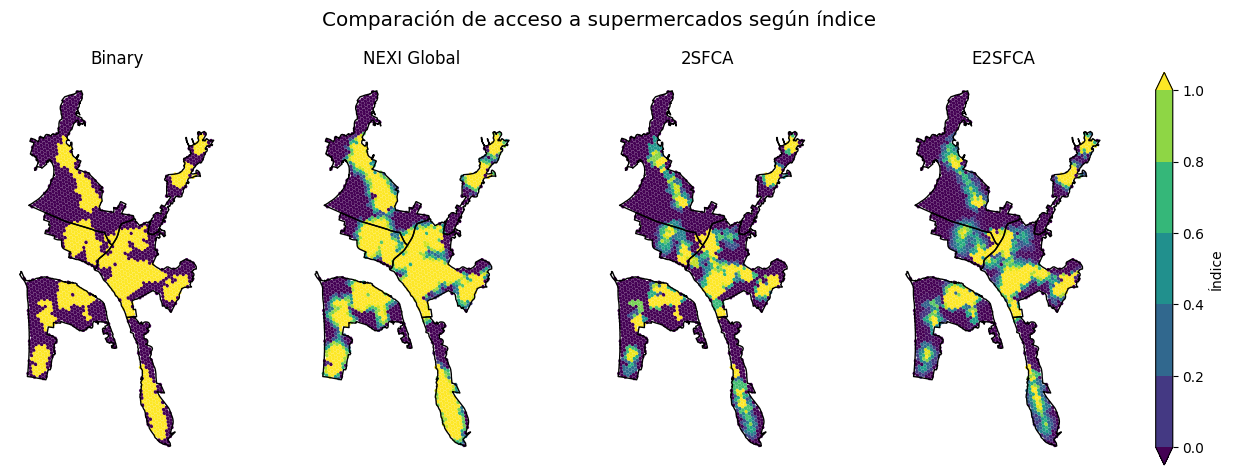

In [35]:
fig = plt.figure(figsize=(2 * 6.4, 4.8))
gs = GridSpec(1, 5, figure=fig, width_ratios=[50, 50, 50, 50, 3])
ax_binary = fig.add_subplot(gs[0, 0])
ax_nexi = fig.add_subplot(gs[0, 1])
ax_2sfca = fig.add_subplot(gs[0, 2])
ax_e2sfca = fig.add_subplot(gs[0, 3])
ax_cb = fig.add_subplot(gs[0, 4])

norm = mcolors.BoundaryNorm(
    [1e-10, 0.2, 0.4, 0.6, 0.8, 1.0], ncolors=256, extend="both"
)

for ax, acc, name in zip(
    (ax_binary, ax_nexi, ax_2sfca, ax_e2sfca),
    (acc_binary, acc_nexi, acc_2sfca, acc_e2sfca),
    ("Binary", "NEXI Global", "2SFCA", "E2SFCA"),
):
    acc.visualize.choropleth("total", ax=ax)
    ax.set_axis_off()
    ax.set_title(name)

cbar = plt.cm.ScalarMappable(norm=norm, cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Índice")

fig.suptitle(
    "Comparación de acceso a supermercados según índice",
    fontsize="x-large",
)

plt.tight_layout()
plt.savefig(IMG_PATH / "index_comparison.pdf")

Se observan dos dimensiones en las cuales separar las distintas funciones:

1. **Dicotomía**

    Los índices Binary y 2SFCA tienen una visión dicotómica de la
    accesibilidad: o bien una persona puede acceder en un 100% a la necesidad,
    o no puede acceder en absoluto a la necesidad. Esto se observa a través de
    zonas cuyo índice es 100% pero que están al lado de zonas cuyo índice es
    0%. Por el contrario, NEXI Global y E2SFCA ofrecen una especie de
    "suavizado", donde distancias intermedias acceden a la necesidad en un
    porcentaje entre 0% y 100%.

2. **Oferta y demanda**

    Los índices Binary y NEXI Global no tienen conceptos de oferta y demanda,
    por lo que basta que el origen tenga algún destino dentro de su área de
    accesibilidad para que reciba un índice del 100%. Esto implica que si 50
    mil personas son atendidas por un único destino accesible, todas ellas
    tendrán un índice del 100%, aunque realísticamente es imposible que ese
    único destino pueda satsifacer las necesidades de tantas personas. 2SFCA y
    E2SFCA consideran oferta y demanda en sus cálculos, por lo cual el valor
    del índice dependerá de la cantidad de personas que acceden a cada
    necesidad, no solo si acceden a alguna.

Cada índice tiene sus ventajas y desventajas; permitir una visión no dicotómica
de la accesibilidad, o considerar oferta y demanda, entregan mayores matices al
análisis (en comparación a un índice binario simple). Sin embargo, esta mayor
complejidad implica que se deben definir más parámetros, algunos de los cuales
pueden ser difíciles de definir y/o interpretar.